# Permutation Feature Importance

Permutation Feature Importance (PFI) quantifies how much each input variable contributes to the forecast by measuring the drop in model performance when that variable is randomly shuffled. If a feature is important, permuting its values disrupts meaningful patterns and degrades the forecast.

In this setup, each variable is permuted independently and for each level separately using a binary mask that defines the grid points to shuffle. Each permutation is repeated five times to account for randomness, and results are averaged.

Feature importance is computed as the increase in error (ΔRMSE or ΔMAE) compared to the original forecast. The standard error across repetitions is reported to reflect variability in the importance estimate.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

from pkg.pfi.run_pfi import run_pfi, evaluate_pfi_folder
from pkg.plots.pfi_plots import plot_feature_importance_bar

In [2]:
input_path = "../data/graphcast_small/graphcast_small_zeynep_prediction.nc"
original_prediction_path = "../data/graphcast_small/graphcast_small_zeynep_prediction.nc"

input = xr.open_dataset(input_path)
input_target_last = input.isel(time=-1)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_262/654521437.py:4: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  input = xr.open_dataset(input_path)


### Run PFI 

In [ ]:
variables = [
    "2m_temperature",
    ("10m_u_component_of_wind",
    "10m_v_component_of_wind"),
    "total_precipitation_6hr",
    "mean_sea_level_pressure",
    "temperature",
    ("u_component_of_wind",
    "v_component_of_wind"),
    "geopotential",
    "vertical_velocity",
    "specific_humidity",
]

run_pfi(
    ds_input=input,
    features=variables,
    folder= "variables",
    repetitions=5
)

### Evaluate Results

In [ ]:
summary_df = evaluate_pfi_folder(
    reference=original_prediction_path,
    target=input_target_last,
    folder="../data/pfi/variables"
)


### Plot Results

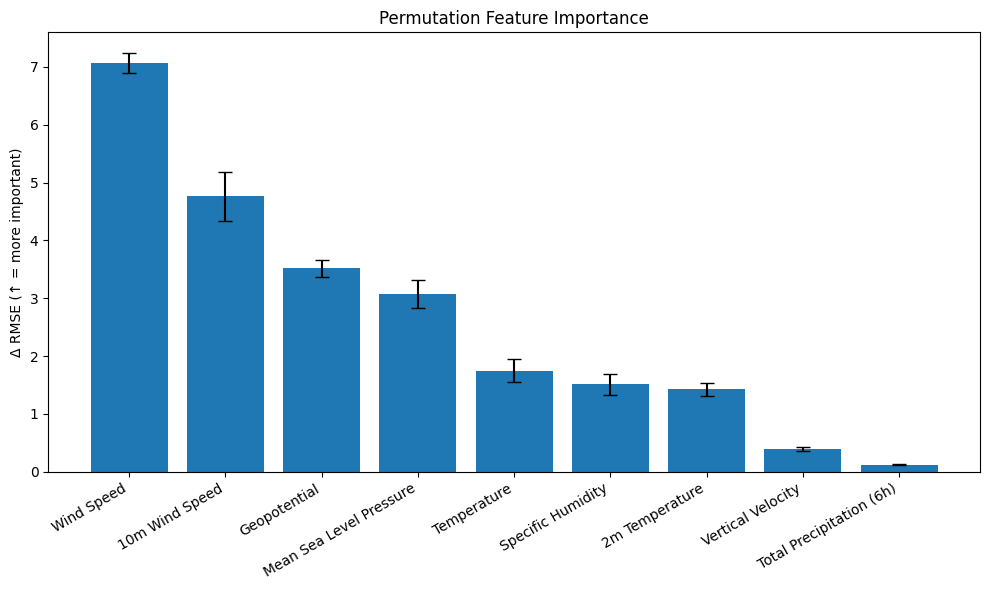

In [4]:
plot_feature_importance_bar(summary_df)